# data load and hieralchical clustering 

In [3]:
#Load packages
library(tidyverse)
library(DESeq2)
library(ggrepel)
library(stringr)
library(limma)
library(ggdendro)
library(ggplot2)
library(pheatmap)
library(clusterProfiler)
library(org.Hs.eg.db)
library(fgsea)
library(msigdbr)
library(impute)
library(eulerr)
library(patchwork)
library(openxlsx)
library(enrichR)

In [5]:
setwd("~/Documents/Paper/MCD_transcriptome_2025/MCDtranscriptome_2024/")

In [6]:
data <- read.csv("input_data_submit/count_matrix_paper_0202.csv",row.names = 1)
meta <- read.csv("input_data_submit/meta_RNA_0202.csv",row.names = 1)

In [7]:
dds_epilepsy <- DESeqDataSetFromMatrix(countData = data, colData = meta, design = ~ Epilepsy)
dds_epilepsy<- DESeq(dds_epilepsy)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1201 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [8]:
vsd <- vst(dds_epilepsy, blind=FALSE)
vst_matrix <- assay(vsd)
dist_matrix <- dist(t(vst_matrix), method = "euclidean")
hc <- hclust(dist_matrix, method = "ward.D2")

dend <- as.dendrogram(hc)
dend_data <- dendro_data(dend)

sample_order <- dend_data$labels$label
annotation <- as.data.frame(colData(dds_epilepsy)[, c("Diagnosis","Sex","Age_at_surgery")]) 
colnames(annotation) <-c("Group","Sex","Age_at_surgery")
annotation$Sample <- rownames(annotation)
annotation$Sample <- factor(annotation$Sample, levels = sample_order)


Fig2A

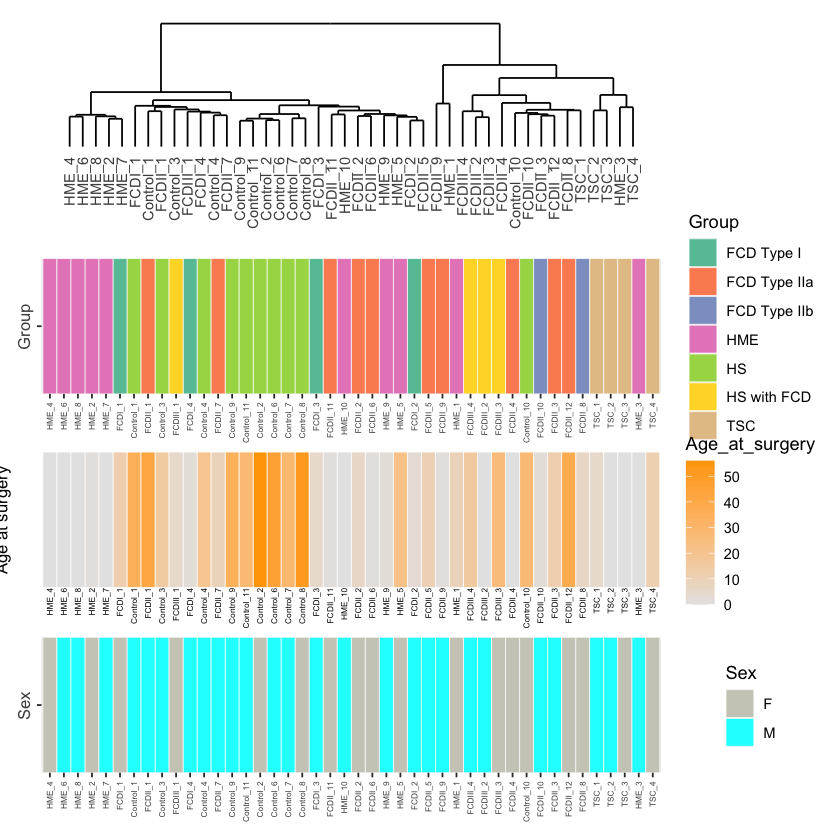

In [9]:
p1 <- ggdendrogram(hc, rotate = FALSE, theme_dendro = TRUE) +  
  theme(plot.margin = margin(5, 5, 0, 5, "pt"), axis.text.y = element_blank())
# Annotation bar plot
p2 <- ggplot(annotation, aes(x = Sample, y = "Group", fill = Group)) +
  geom_tile(color = "white",
            lwd = 0.2,
            linetype = 1)+
  scale_y_discrete(expand = c(0, 0))+
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5,size = 5),
        axis.title.x = element_blank(),
        axis.title.y =  element_blank(),
        axis.text.y = element_text(angle = 90,hjust = 0.5,vjust = 1,size = 10),
        panel.grid = element_blank())+ scale_fill_brewer(palette = "Set2")

p3 <- ggplot(annotation, aes(x = Sample, y = "Age at surgery", fill = Age_at_surgery)) +
  geom_tile(color = "white",
            lwd = 0.2,
            linetype = 1)+
  scale_y_discrete(expand = c(0, 0)) +
  theme_void() +
   theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5,size = 5),
        axis.title.x = element_blank(),
        axis.title.y =  element_blank(),
        axis.text.y = element_text(angle = 90,hjust = 0.5,vjust = 3,size = 10),
        panel.grid = element_blank()) +
  scale_fill_gradient(low = "grey90",high = "orange")

p4 <- ggplot(annotation, aes(x = Sample, y = "Sex", fill = Sex)) +
  geom_tile(color = "white",
            lwd = 0.2,
            linetype = 1) +
  scale_y_discrete(expand = c(0, 0))+
   theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5,size = 5),
        axis.title.x = element_blank(),
        axis.title.y =  element_blank(),
        axis.text.y = element_text(angle = 90,hjust = 0.5,vjust = 1,size = 10),
        panel.grid = element_blank()) + scale_fill_manual(values = c("ivory3","cyan1"))

# Combine dendrogram and annotation using patchwork

p1 / p2 / p3 / p4

# DEG analysis control vs mTOR

In [10]:
meta%>% filter(mTORopathy %in% c("Control", "mTOR")) -> meta_mTOR

In [11]:
count_matrix_mTOR <- data[,  meta_mTOR$sample_name] 

In [12]:
identical(rownames(meta_mTOR),colnames(count_matrix_mTOR))

[1] TRUE

In [13]:
dds_mTOR <-
DESeqDataSetFromMatrix(
    countData = count_matrix_mTOR, 
    colData = meta_mTOR, 
    design = ~ mTORopathy)
dds_mTOR<- DESeq(dds_mTOR)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1096 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [14]:
resLFC_ncnp <- lfcShrink(dds_mTOR, coef = 'mTORopathy_mTOR_vs_Control',type="ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



Volcanoplot Fig3A

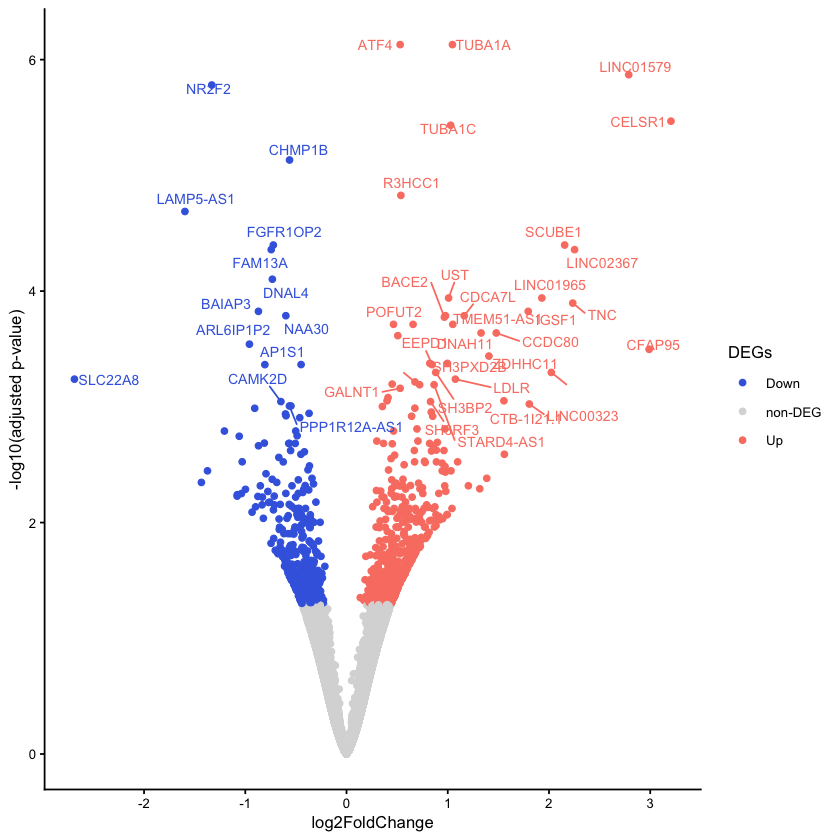

In [26]:
resLFC_ncnp %>% data.frame() %>%mutate(FC = resLFC_ncnp$log2FoldChange) %>%  drop_na()  %>% 
mutate(DEGs = ifelse(padj < 0.05 & log2FoldChange > 0, "Up",
                  ifelse(padj < 0.05 & log2FoldChange < 0, "Down", "non-DEG"))) %>%
mutate(gene2plot = ifelse(-log10(padj) > 3&abs(log2FoldChange) > 0.5, row.names(.), ""))%>% arrange(-baseMean) %>%
mutate(gene2plot = if_else(str_sub(gene2plot,start = 1, end = 3) == "ENS", " ", gene2plot)) %>%
ggplot(aes(x = log2FoldChange, y = -log10(padj), color = DEGs,label=gene2plot ))+
geom_point() + geom_text_repel(max.overlaps = 50,show.legend =FALSE,size = 3)+
scale_color_manual(values = c("royalblue","grey85","salmon")) + theme_classic()+
ylab("-log10(adjusted p-value)")+theme(text = element_text(size = 10))

#resLFC_ncnp %>% data.frame() %>% filter(padj < 0.05 & log2FoldChange > 0) #TableS3_upDEG_ncnp
#resLFC_ncnp %>% data.frame() %>% filter(padj < 0.05 & log2FoldChange < 0) #TableS4_downDEG_ncnp.xlsx

## cross data comparison

In [28]:
natcom2_active_mTOR <- read.csv("./input_data_submit/nat_com_count_matrix.csv",row.names = 1)
meta_nat_mTOR <- read.csv("./input_data_submit/nat_com_meta.csv",row.names = 1)

In [29]:
identical(row.names(meta_nat_mTOR),colnames(natcom2_active_mTOR))

[1] TRUE

In [30]:
dds_natcom <- DESeqDataSetFromMatrix(countData = natcom2_active_mTOR, colData = meta_nat_mTOR, design = ~mTOR )
dds_natcom <- DESeq(dds_natcom)
resLFC_natcom <- lfcShrink(dds_natcom,coef = "mTOR_mTOR_vs_Control", type = "ashr")

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 355 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



In [31]:
resLFC_ncnp%>%data.frame() %>% filter(padj < 0.05 & log2FoldChange > 0) -> up_DEG
resLFC_ncnp%>%data.frame() %>% filter(padj < 0.05 & log2FoldChange < 0) -> down_DEG

resLFC_natcom %>%data.frame() %>% filter(padj < 0.05 & log2FoldChange > 0) -> up_DEG_nc
resLFC_natcom %>%data.frame() %>% filter(padj < 0.05 & log2FoldChange < 0) -> down_DEG_nc

common_up <- intersect(row.names(up_DEG), row.names(up_DEG_nc)) #TableS5_common_up
common_dn <- intersect(row.names(down_DEG), row.names(down_DEG_nc)) #TableS5_common_down

In [32]:
dim(up_DEG)
dim(down_DEG)
dim(up_DEG_nc)
dim(down_DEG_nc)

[1] 650   5

[1] 395   5

[1] 3024    5

[1] 3583    5

In [33]:
length(common_up)
length(common_dn)

[1] 115

[1] 52

Fig3B

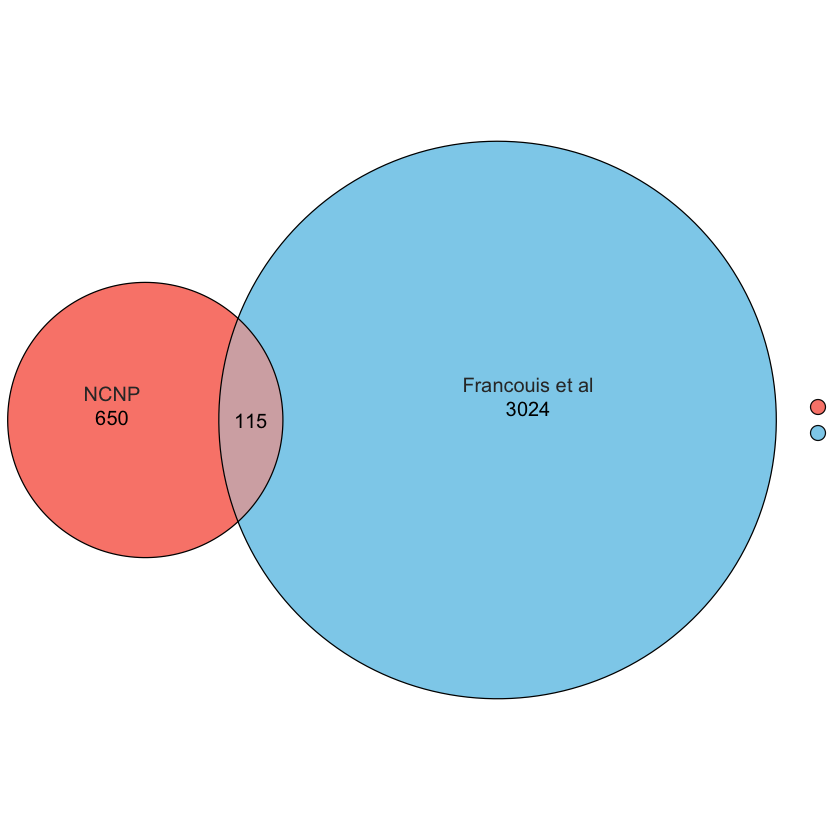

In [34]:
#Figure3B Venn diagram
A = nrow(up_DEG)
B = nrow(up_DEG_nc)
AB = length(common_up)

fit = euler(c('NCNP'=A,'Francouis et al'=B,'NCNP&Francouis et al'=AB),shape = "ellipse")
name_A = ""
name_B = ""
plot(fit,
    　fills = list(fill = c("salmon","skyblue"),
    　alpha = 0.95),
    　labels = list(col = "#333333", font = 1),
    　quantities = TRUE,
    　legend = list(labels = c(name_A, name_B))
    )

Fig.3C

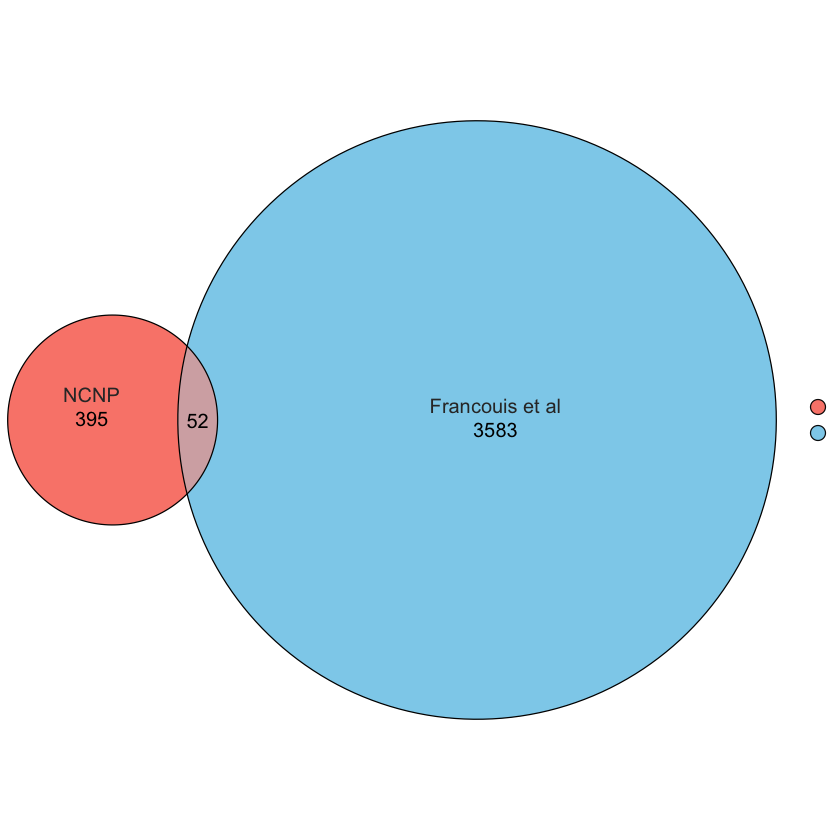

In [35]:
#Figure3C Venn diagram
A = nrow(down_DEG)
B = nrow(down_DEG_nc)
AB = length(common_dn)

fit = euler(c('NCNP'=A,'Francouis et al'=B,'NCNP&Francouis et al'=AB),shape = "ellipse")
name_A = ""
name_B = ""
plot(fit,
    　fills = list(fill = c("salmon","skyblue"),
    　alpha = 0.95),
    　labels = list(col = "#333333", font = 1),
    　quantities = TRUE,
    　legend = list(labels = c(name_A, name_B))
    )

## GO analysis

In [36]:
univ <- intersect(row.names(resLFC_ncnp), row.names(resLFC_natcom))

In [37]:
websiteLive <- getOption("enrichR.live")

if (websiteLive) {
    dbs <- listEnrichrDbs()
    head(dbs)
}

,geneCoverage,genesPerTerm,libraryName,link,numTerms,appyter,categoryId
,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>
1,13362,275,Genome_Browser_PWMs,http://hgdownload.cse.ucsc.edu/goldenPath/hg18/database/,615,ea115789fcbf12797fd692cec6df0ab4dbc79c6a,1
2,27884,1284,TRANSFAC_and_JASPAR_PWMs,http://jaspar.genereg.net/html/DOWNLOAD/,326,7d42eb43a64a4e3b20d721fc7148f685b53b6b30,1
3,6002,77,Transcription_Factor_PPIs,,290,849f222220618e2599d925b6b51868cf1dab3763,1
4,47172,1370,ChEA_2013,http://amp.pharm.mssm.edu/lib/cheadownload.jsp,353,7ebe772afb55b63b41b79dd8d06ea0fdd9fa2630,7
5,47107,509,Drug_Perturbations_from_GEO_2014,http://www.ncbi.nlm.nih.gov/geo/,701,ad270a6876534b7cb063e004289dcd4d3164f342,7
6,21493,3713,ENCODE_TF_ChIP-seq_2014,http://genome.ucsc.edu/ENCODE/downloads.html,498,497787ebc418d308045efb63b8586f10c526af51,7


In [39]:
dbs <- c("GO_Molecular_Function_2025", "GO_Biological_Process_2025")

In [40]:
if (websiteLive) {
    enriched <- enrichr(common_up, dbs, background = univ)
}

Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - GO_Molecular_Function_2025... Done.
 - GO_Biological_Process_2025... Done.
Parsing results... Done.


In [41]:
if (websiteLive) {
    enriched2 <- enrichr(common_dn, dbs, background = univ)
}

Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - GO_Molecular_Function_2025... Done.
 - GO_Biological_Process_2025... Done.
Parsing results... Done.


Fig. 3D

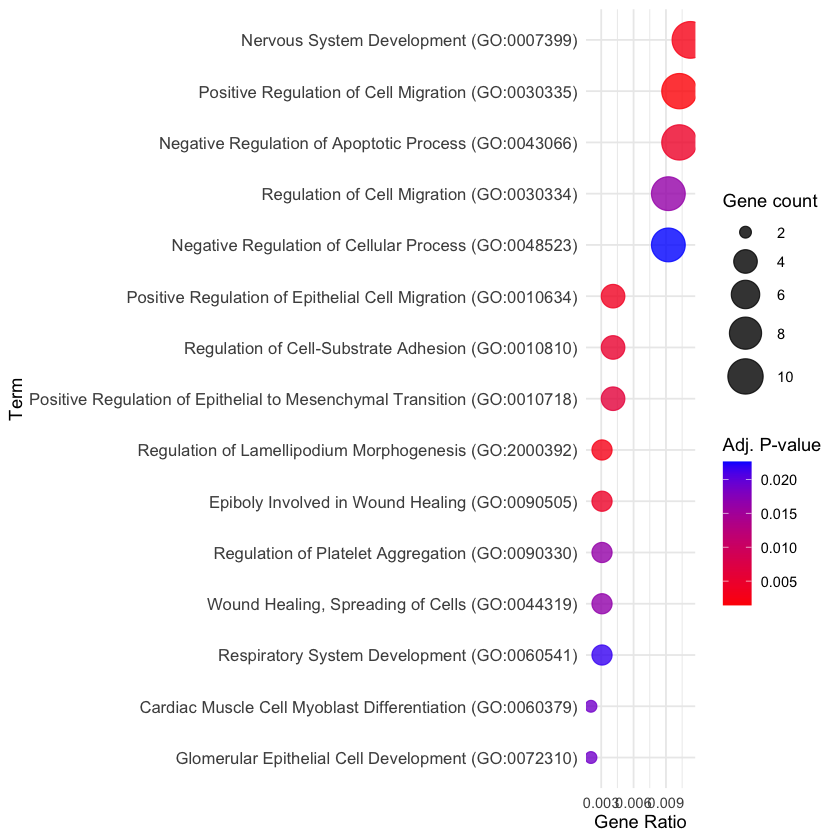

In [42]:
up_BP <- enriched$GO_Biological_Process_2025 #Table S6
up_BP %>%
  mutate(
    GeneCount = sapply(strsplit(Genes, ";"), length),
    Term = factor(Term, levels = rev(Term)),
    GeneRatio = GeneCount / length(row.names(.))  # keeps top term at top
  )%>% filter(Adjusted.P.value< 0.05)%>% head(n= 15) %>%
  mutate(Term = fct_reorder(Term, GeneRatio,.desc = FALSE))%>%
ggplot(aes(
  x = GeneRatio,
  y = Term,
  size = GeneCount,
  color = Adjusted.P.value
)) +
  geom_point(alpha = 0.8) +
  scale_color_gradient(low = "red", high = "blue", name = "Adj. P-value") +
  scale_size(range = c(3, 10), name = "Gene count") +
  labs(
    x = "Gene Ratio"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size =10),
    plot.title = element_text(hjust = 0.5)
  )

Fig. 3E

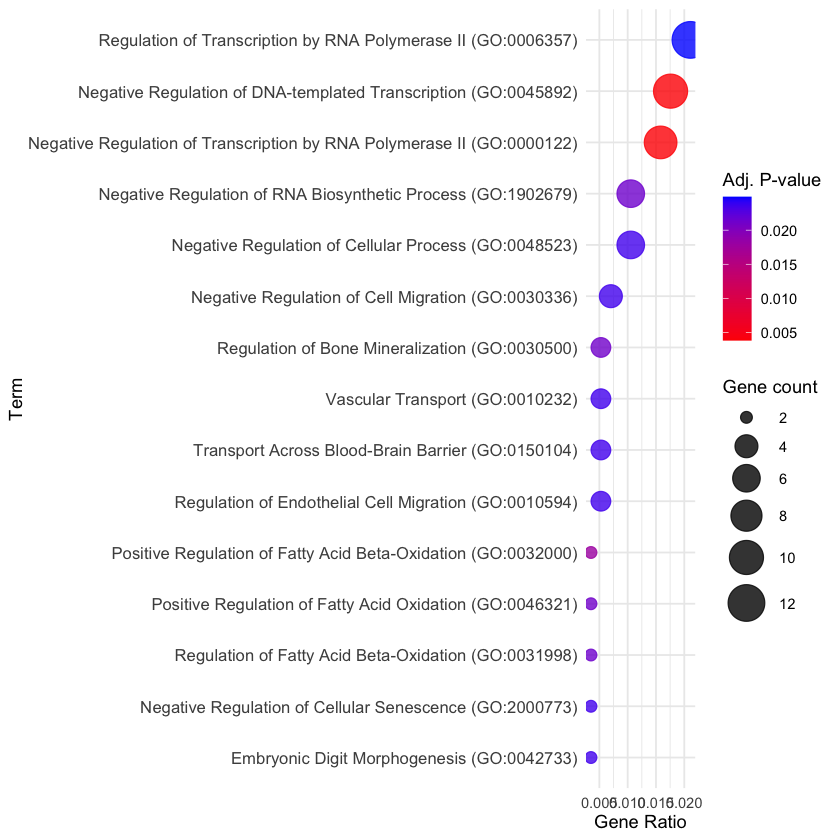

In [43]:
down_BP <- enriched2$GO_Biological_Process_2025 #Table S6
down_BP %>%
  mutate(
    GeneCount = sapply(strsplit(Genes, ";"), length),
    Term = factor(Term, levels = rev(Term)),
    GeneRatio = GeneCount / length(row.names(.))  # keeps top term at top
  )%>% filter(Adjusted.P.value< 0.05)%>% head(n= 15) %>%
  mutate(Term = fct_reorder(Term, GeneRatio,.desc = FALSE))%>%
ggplot(aes(
  x = GeneRatio,
  y = Term,
  size = GeneCount,
  color = Adjusted.P.value
)) +
  geom_point(alpha = 0.8) +
  scale_color_gradient(low = "red", high = "blue", name = "Adj. P-value") +
  scale_size(range = c(3, 10), name = "Gene count") +
  labs(
    x = "Gene Ratio"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size =10),
    plot.title = element_text(hjust = 0.5)
  )

## GSEA analysis

In [44]:
resLFC_ncnp%>% data.frame() %>% drop_na() %>% dplyr::select(log2FoldChange) -> resLFC_stat
rank <- resLFC_stat$log2FoldChange
names(rank) <- row.names(resLFC_stat)

In [45]:
set.seed(901)
hallmark_collection <- msigdbr(species = "Homo sapiens", collection = "H")
hallmark_pathways <- hallmark_collection %>%
  split(x = .$gene_symbol, f = .$gs_name)

In [46]:
fgsea_result <- fgsea(pathways = hallmark_pathways, 
                                stats = rank,
                                eps = 0.0,
                                minSize = 15,
                                maxSize = 500) 

Fig. 4A

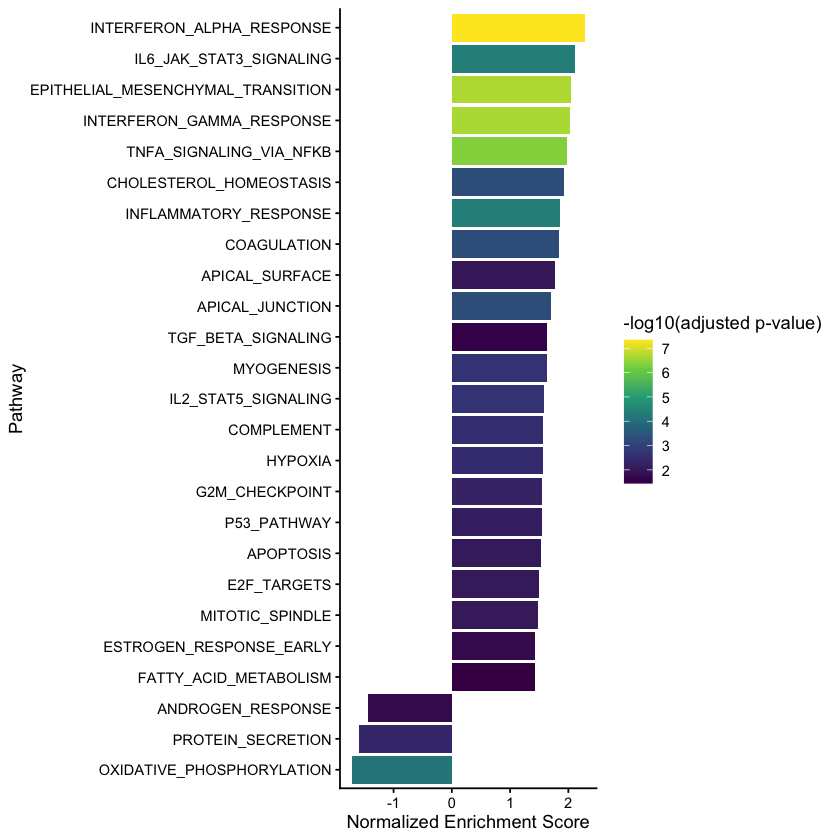

In [47]:
fgsea_result %>% filter(padj < 0.05) %>% mutate(p.adjust = -log10(padj)) %>% 
mutate(pathway = str_sub(pathway,start = 10,end = -1)) %>%
ggplot(aes(x=reorder(pathway, NES), y= NES)) +geom_col(aes(fill=p.adjust))+
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",fill = "-log10(adjusted p-value)") + 
theme(text = element_text(size = 30))+theme_classic() +scale_fill_viridis_c()

In [48]:
resLFC_natcom%>% data.frame() %>% drop_na() %>% dplyr::select(log2FoldChange) -> resLFC_stat_natcom
rank_natcom <- resLFC_stat_natcom$log2FoldChange
names(rank_natcom) <- row.names(resLFC_stat_natcom)

In [49]:
fgsea_result_natcom <- fgsea(pathways = hallmark_pathways, 
                                stats = rank_natcom,
                                eps = 0.0,
                                minSize = 15,
                                maxSize = 500) 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


Fig.4B

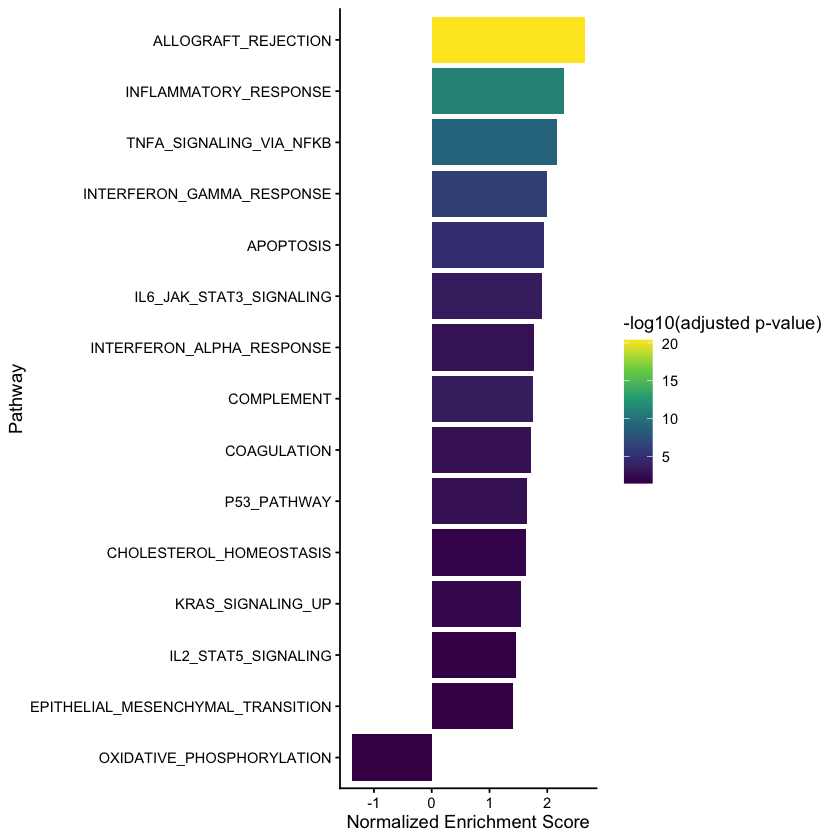

In [50]:
fgsea_result_natcom %>% filter(padj < 0.05) %>% mutate(p.adjust = -log10(padj)) %>% 
mutate(pathway = str_sub(pathway,start = 10,end = -1)) %>%
ggplot(aes(x=reorder(pathway, NES), y= NES)) +geom_col(aes(fill=p.adjust))+
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",fill = "-log10(adjusted p-value)") + 
theme(text = element_text(size = 20))+theme_classic() +scale_fill_viridis_c()

Fig. 4C,D

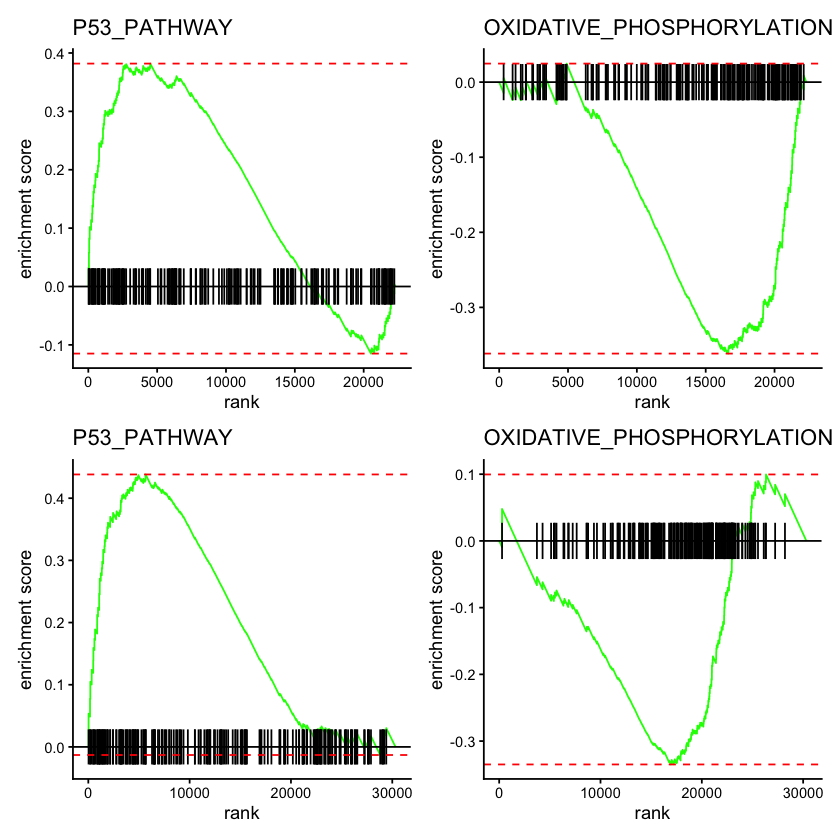

In [51]:
p1 <- plotEnrichment(hallmark_pathways[['HALLMARK_P53_PATHWAY']],
               rank, gseaParam = 1, ticksSize = 0.5)+ labs(title="P53_PATHWAY")+ 
theme(text = element_text(size = 20))+theme_classic()

p2 <- plotEnrichment(hallmark_pathways[['HALLMARK_P53_PATHWAY']],
               rank_natcom, gseaParam = 1, ticksSize = 0.5)+ labs(title="P53_PATHWAY")+ 
theme(text = element_text(size = 20))+theme_classic()

p3 <-plotEnrichment(hallmark_pathways[['HALLMARK_OXIDATIVE_PHOSPHORYLATION']],
               rank, gseaParam = 1, ticksSize = 0.5)+ labs(title="OXIDATIVE_PHOSPHORYLATION")+ 
theme(text = element_text(size = 20))+theme_classic()

p4 <- plotEnrichment(hallmark_pathways[['HALLMARK_OXIDATIVE_PHOSPHORYLATION']],
               rank_natcom, gseaParam = 1, ticksSize = 0.5)+ labs(title="OXIDATIVE_PHOSPHORYLATION")+ 
theme(text = element_text(size = 20))+theme_classic()

(p1 + p3)  / (p2 + p4)

# Proteomics

In [52]:
gl.exp <- read.csv("./input_data_submit/proteomics_gene_level_0204.csv",row.names = 1)
proteomics_meta <- read.csv("./input_data_submit/proteomics_meta_0204.csv",row.names = 1)
gl.exp  %>% na.omit -> gl_omit.exp 
gl.log <- log(gl_omit.exp +1 )
proteomics_meta %>% filter(mTORopathy %in% c("Control", "mTOR")) -> proteomics_meta_mTOR
gl_mTOR.log <- gl.log[,row.names(proteomics_meta_mTOR)]
colData <- data.frame(mTOR = proteomics_meta_mTOR$mTORopathy)
design <- model.matrix(~ colData$mTOR)
fit <- lmFit(gl_mTOR.log, design)
fit <- eBayes(fit)
res <- topTable(fit, coef = 2, number = Inf, adjust = "BH")

In [53]:
res %>%  filter(adj.P.Val < 0.2& abs(logFC) > log(1.2)) #TableS7

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CPNE5,-0.7580054,14.10866,-4.935184,3.263661e-05,0.06646724,2.2893462
DNAJB2,-0.5614333,13.67094,-4.742532,5.533826e-05,0.06646724,1.8288871
PAM,-1.0760985,12.19501,-4.606252,8.035812e-05,0.06646724,1.5031292
DNAJC5,-1.0669445,14.37837,-4.486487,1.114658e-04,0.06646724,1.2171251
TMX3,-0.4884693,12.64105,-4.375899,1.506834e-04,0.06646724,0.9534864
C1QL3,-1.0556456,11.91104,-4.347563,1.627634e-04,0.06646724,0.8860280
PCSK1,-1.0076801,10.76135,-4.314730,1.779638e-04,0.06646724,0.8079212
MTMR12,-0.5272800,11.62661,-4.240103,2.179349e-04,0.06646724,0.6306473
NDUFS4,-0.6567417,14.71065,-4.238539,2.188612e-04,0.06646724,0.6269365


In [55]:
genes2compare <- intersect(row.names(resLFC_ncnp),row.names(res))

In [56]:
gene_expressions.df <- data.frame(RNAseq = resLFC_ncnp[genes2compare, ]$log2FoldChange, Proteomics = res[genes2compare,]$logFC,row.names = genes2compare)

In [57]:
gene_expressions.df <- gene_expressions.df %>%
    mutate(size = abs(RNAseq * Proteomics))%>% 
    mutate(group = 
           case_when(
               RNAseq > 0.2 & Proteomics > 0.2~ "UP",
               RNAseq < -0.2 & Proteomics < -0.2 ~ "DOWN",
               TRUE ~ "none")
          )%>% 
    mutate(gene2plot = 
           case_when(
                RNAseq > 0.2 & Proteomics >0.2~ row.names(.),
                RNAseq < -0.2 & Proteomics < -0.2~ row.names(.),
                TRUE ~ "")
          )

Fig.5A

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 307 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


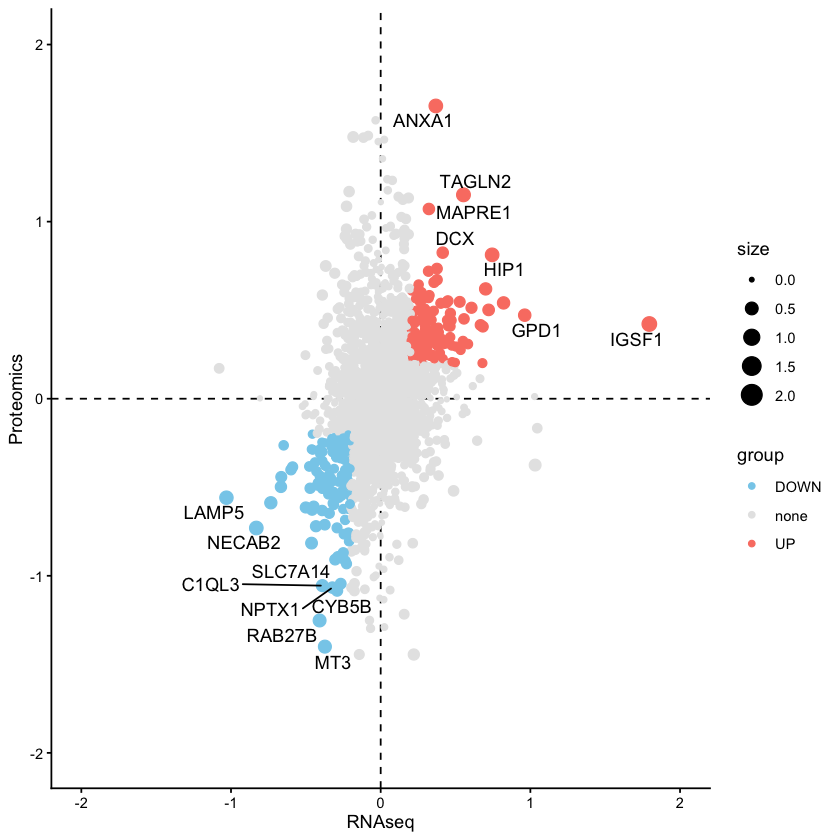

In [58]:
gene_expressions.df %>% ggplot() +
geom_vline(xintercept = 0,linetype = 2,color = "black")+geom_hline(yintercept = 0,linetype = 2,color = "black")+
geom_point(aes(x =RNAseq, y = Proteomics,size = size,color = group)) +
geom_text_repel(aes(x =RNAseq, y = Proteomics,label=gene2plot),max.overlaps = 20)+theme(text = element_text(size = 30))+
ylim(-2,2)+xlim(-2,2) + theme_classic() +scale_color_manual(values = c("skyblue", "grey90","salmon"))

Correlation

In [59]:
cor(gene_expressions.df$Proteomics,gene_expressions.df$RNAseq)
lm.fit = lm(gene_expressions.df$Proteomics~gene_expressions.df$RNAseq)
R2 = summary(lm.fit)$r.squared
R2
cor.test(gene_expressions.df$Proteomics,gene_expressions.df$RNAseq)


[1] 0.2897374

[1] 0.08394779


	Pearson's product-moment correlation

data:  gene_expressions.df$Proteomics and gene_expressions.df$RNAseq
t = 17.904, df = 3498, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2590931 0.3197991
sample estimates:
      cor 
0.2897374 


Fig.5B

In [86]:
dim(gl_omit.exp)
dim(gene_expressions.df)

[1] 3523   35

[1] 3500    5

Warning message:
“ggrepel: 113 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


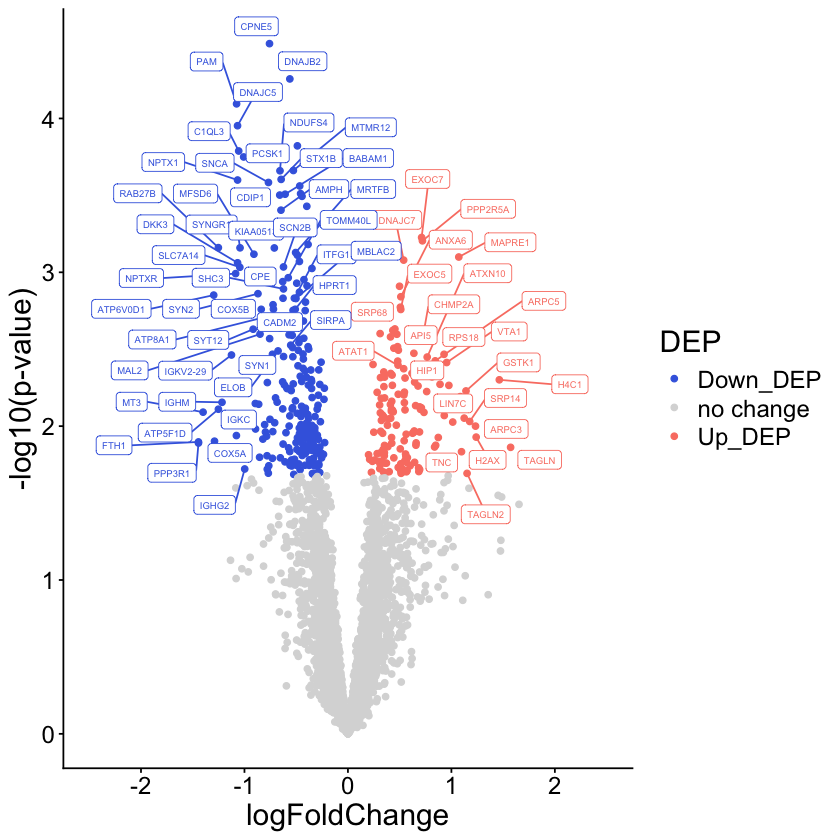

In [64]:
res%>% data.frame()  -> volcano.df
volcano.df %>%mutate(FC = res$logFC) %>%  drop_na()  %>% 
mutate(DEP = ifelse(adj.P.Val < 0.2 &  logFC > log(1.2), "Up_DEP",
              ifelse(adj.P.Val < 0.2 &  logFC < -log(1.2), "Down_DEP", "no change"))) %>%
mutate(gene2plot = ifelse(DEP %in% c("Up_DEP","Down_DEP") &abs(logFC) > 0.5 , row.names(.), "")) -> volcano.df

volcano.df %>% ggplot(aes(x = FC, y = -log10(P.Value), color = DEP,label=gene2plot ))+
geom_point() + geom_label_repel(max.overlaps = 30,show.legend =FALSE,size = 2)+
scale_color_manual(values = c("royalblue","grey85","salmon")) + theme_classic()+
ylab("-log10(p-value)")+xlab("logFoldChange")+theme(text = element_text(size = 18)) +xlim(-2.5,2.5) 

In [65]:
ggsave("./output_figure_submit/Figure5B_volcano.pdf")

Saving 6.67 x 6.67 in image
Warning message:
“ggrepel: 114 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [87]:
res %>% filter(adj.P.Val < 0.2 & logFC> log(1.2)) %>% dim
res %>% filter(adj.P.Val < 0.2 & logFC< -log(1.2)) %>% dim

[1] 141   6

[1] 223   6

In [66]:
target_gene <- c("COX5B","NDUFS4","GOT2","DKK3","RAB27B")

In [68]:
gl.log[target_gene, ] %>% t() -> gl_target.log

Fig.5C

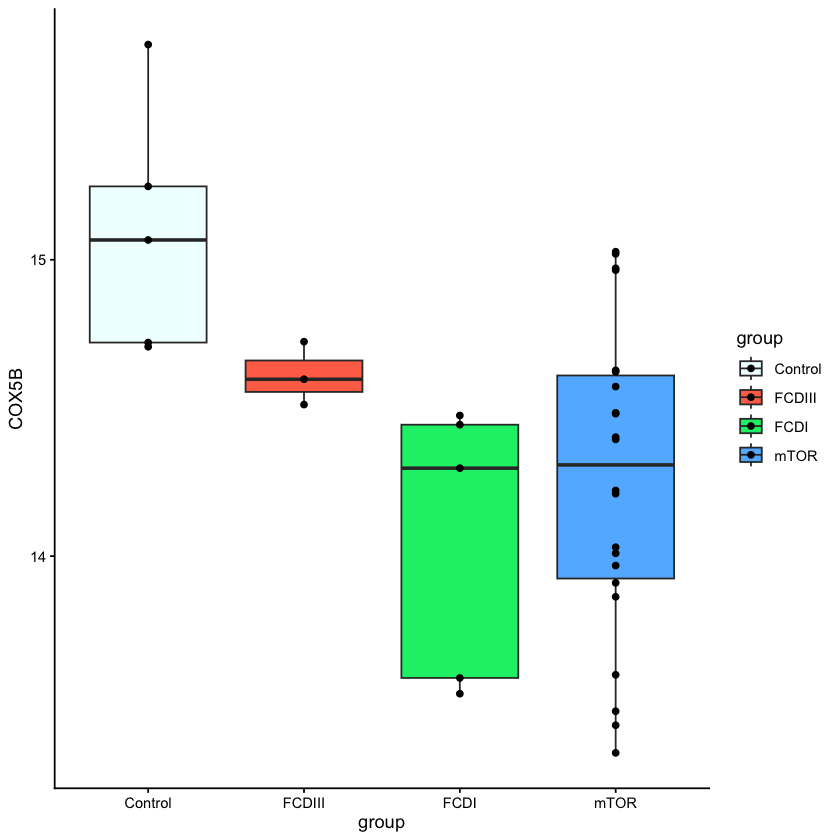

In [69]:
gl_target.log %>% as.data.frame() %>% mutate(group =factor(proteomics_meta$Group,levels = c("Control","FCDIII","FCDI","mTOR"))) %>% 
ggplot(aes(x = group, y = COX5B,fill = group)) +geom_boxplot() +geom_point() +theme_classic() +
scale_fill_manual(values = c("azure","coral1","springgreen2","steelblue1"))

In [71]:
ggsave("./output_figure_submit/Figure5C_COX5B.pdf")

Saving 6.67 x 6.67 in image


In [72]:
TukeyHSD(aov(gl_target.log[,"COX5B"]~proteomics_meta$Group))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = gl_target.log[, "COX5B"] ~ proteomics_meta$Group)

$`proteomics_meta$Group`
                     diff        lwr        upr     p adj
FCDI-Control   -1.0256155 -1.8616458 -0.1895853 0.0114772
FCDIII-Control -0.4829696 -1.4483342  0.4823950 0.5344027
mTOR-Control   -0.8381575 -1.4930613 -0.1832536 0.0079514
FCDIII-FCDI     0.5426459 -0.4227187  1.5080105 0.4349439
mTOR-FCDI       0.1874581 -0.4674458  0.8423619 0.8643028
mTOR-FCDIII    -0.3551878 -1.1687487  0.4583730 0.6406964


Fig.5D

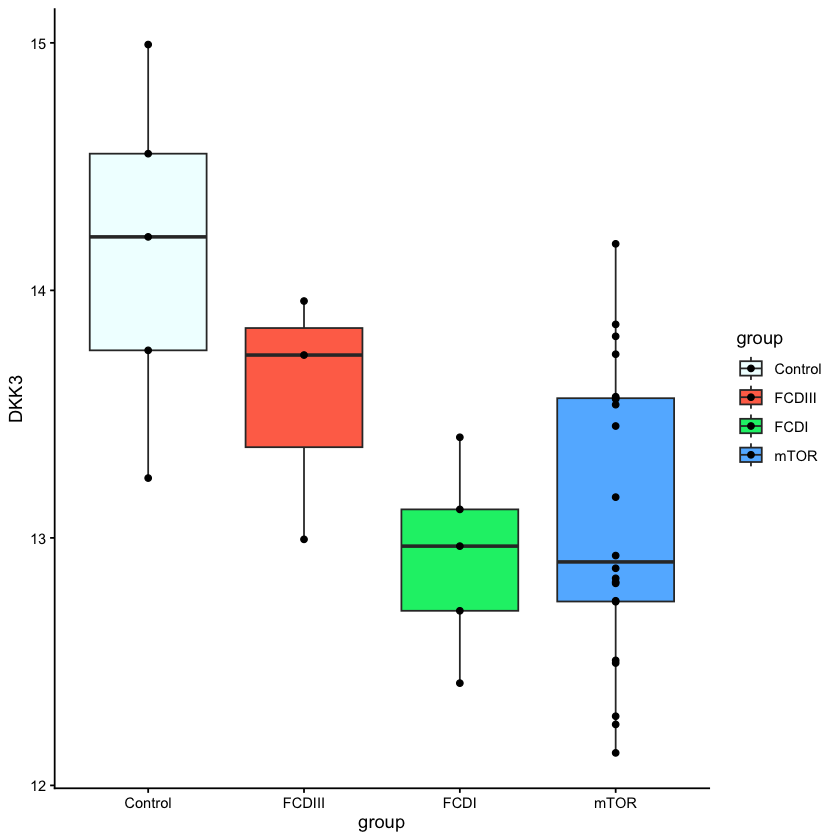

In [73]:
gl_target.log %>% as.data.frame() %>% mutate(group =factor(proteomics_meta$Group,levels = c("Control","FCDIII","FCDI","mTOR"))) %>% 
ggplot(aes(x = group, y = DKK3,fill = group)) +geom_boxplot() +geom_point() +theme_classic() +
scale_fill_manual(values = c("azure","coral1","springgreen2","steelblue1"))

In [74]:
ggsave("./output_figure_submit/Figure5D_DKK3.pdf")

Saving 6.67 x 6.67 in image


In [75]:
TukeyHSD(aov(gl_target.log[,"DKK3"]~proteomics_meta$Group))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = gl_target.log[, "DKK3"] ~ proteomics_meta$Group)

$`proteomics_meta$Group`
                     diff        lwr        upr     p adj
FCDI-Control   -1.2308030 -2.2163998 -0.2452062 0.0098641
FCDIII-Control -0.5889481 -1.7270172  0.5491211 0.5061114
mTOR-Control   -1.0665543 -1.8386210 -0.2944876 0.0038646
FCDIII-FCDI     0.6418550 -0.4962142  1.7799241 0.4320490
mTOR-FCDI       0.1642487 -0.6078180  0.9363155 0.9381126
mTOR-FCDIII    -0.4776062 -1.4367138  0.4815014 0.5382579


Fig.5E

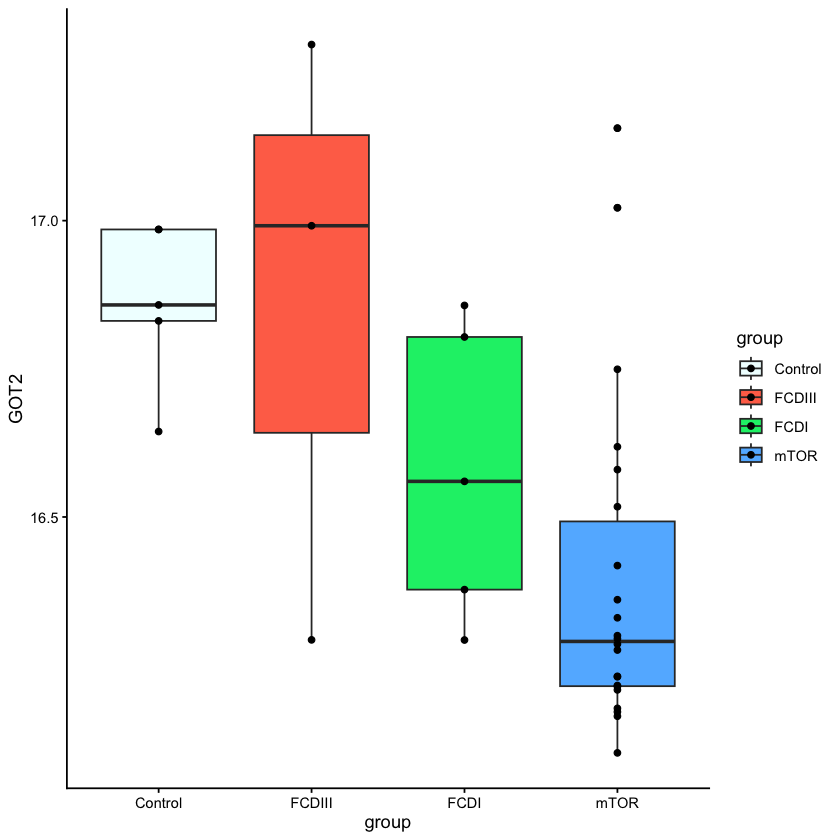

In [76]:
gl_target.log %>% as.data.frame() %>% mutate(group =factor(proteomics_meta$Group,levels = c("Control","FCDIII","FCDI","mTOR"))) %>% 
ggplot(aes(x = group, y = GOT2,fill = group)) +geom_boxplot() +geom_point() +theme_classic() +
scale_fill_manual(values = c("azure","coral1","springgreen2","steelblue1"))

In [78]:
ggsave("./output_figure_submit/Figure5E_GOT2.pdf")

Saving 6.67 x 6.67 in image


In [77]:
TukeyHSD(aov(gl_target.log[,"GOT2"]~proteomics_meta$Group))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = gl_target.log[, "GOT2"] ~ proteomics_meta$Group)

$`proteomics_meta$Group`
                        diff        lwr          upr     p adj
FCDI-Control   -0.2825026628 -0.7697777  0.204772347 0.4079787
FCDIII-Control -0.0002311603 -0.5628879  0.562425556 1.0000000
mTOR-Control   -0.4688032155 -0.8505098 -0.087096603 0.0113670
FCDIII-FCDI     0.2822715026 -0.2803852  0.844928219 0.5321226
mTOR-FCDI      -0.1863005527 -0.5680072  0.195406060 0.5546978
mTOR-FCDIII    -0.4685720552 -0.9427509  0.005606796 0.0537098


Fig.5F

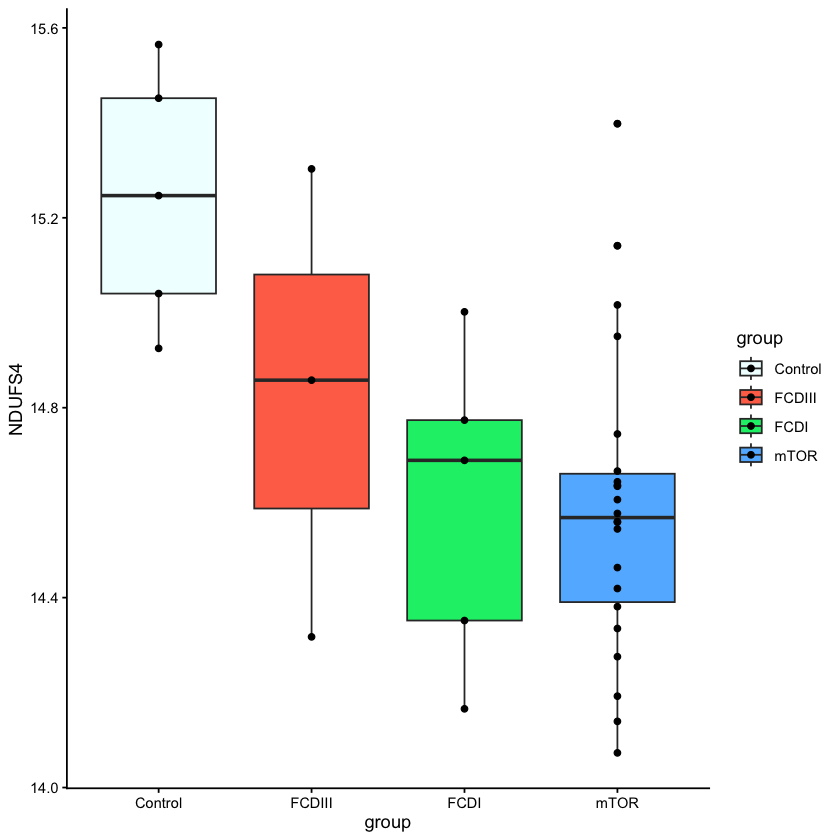

In [79]:
gl_target.log %>% as.data.frame() %>% mutate(group =factor(proteomics_meta$Group,levels = c("Control","FCDIII","FCDI","mTOR"))) %>% 
ggplot(aes(x = group, y = NDUFS4,fill = group)) +geom_boxplot() +geom_point() +theme_classic() +
scale_fill_manual(values = c("azure","coral1","springgreen2","steelblue1"))

In [80]:
TukeyHSD(aov(gl_target.log[,"NDUFS4"]~proteomics_meta$Group))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = gl_target.log[, "NDUFS4"] ~ proteomics_meta$Group)

$`proteomics_meta$Group`
                       diff        lwr         upr     p adj
FCDI-Control   -0.649292936 -1.2192204 -0.07936551 0.0206693
FCDIII-Control -0.419664755 -1.0777603  0.23843075 0.3255204
mTOR-Control   -0.656741675 -1.1031940 -0.21028934 0.0020115
FCDIII-FCDI     0.229628182 -0.4284673  0.88772368 0.7798963
mTOR-FCDI      -0.007448739 -0.4539011  0.43900359 0.9999659
mTOR-FCDIII    -0.237076920 -0.7916868  0.31753295 0.6558212


In [81]:
ggsave("./output_figure_submit/Figure5F_NDUFS4.pdf")

Saving 6.67 x 6.67 in image


Fig.5G

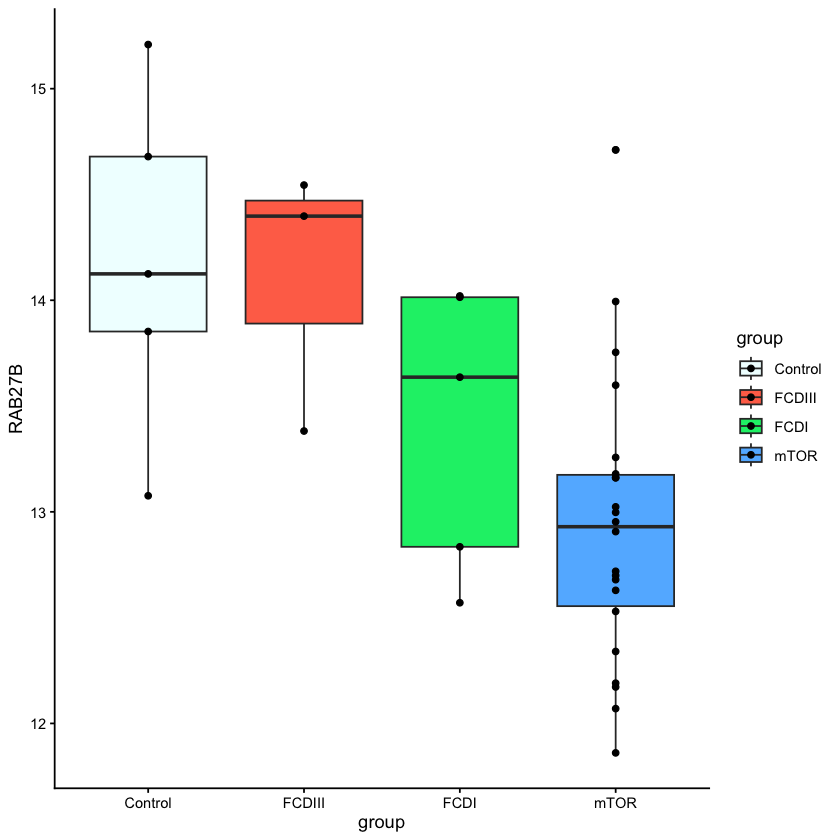

In [82]:
gl_target.log  %>% as.data.frame() %>% mutate(group =factor(proteomics_meta$Group,levels = c("Control","FCDIII","FCDI","mTOR"))) %>% 
ggplot(aes(x = group, y = RAB27B,fill = group)) +geom_boxplot() +geom_point() +theme_classic() +
scale_fill_manual(values = c("azure","coral1","springgreen2","steelblue1"))

In [83]:
TukeyHSD(aov(gl_target.log[,"RAB27B"]~proteomics_meta$Group))

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = gl_target.log[, "RAB27B"] ~ proteomics_meta$Group)

$`proteomics_meta$Group`
                      diff       lwr        upr     p adj
FCDI-Control   -0.77286021 -1.956679  0.4109590 0.3056718
FCDIII-Control -0.08010846 -1.447065  1.2868483 0.9985354
mTOR-Control   -1.25236881 -2.179713 -0.3250246 0.0048254
FCDIII-FCDI     0.69275176 -0.674205  2.0597085 0.5236923
mTOR-FCDI      -0.47950859 -1.406853  0.4478356 0.5067983
mTOR-FCDIII    -1.17226035 -2.324263 -0.0202578 0.0449035


In [84]:
ggsave("./output_figure_submit/Figure5G_RAB27B.pdf")

Saving 6.67 x 6.67 in image
